# GARCH Volatility Diagnostics

Проверяет volatility-сигнал для минутной `log_return_1m`:

1. Diagnostics: ACF(return), ACF(|return|), ACF(return²), ARCH-LM, Ljung-Box(return²)
2. Baseline GARCH(1,1)
3. Persistence analysis: alpha + beta, conditional volatility dynamics
4. Alternative target forms: GARCH on return, |return|, return²
5. GARCHX baseline: ARX-GARCH with BTC / aggression / pressure / combined exogenous blocks
6. Model comparison: AIC/BIC, OOS volatility RMSE, variance RMSE, correlations, regime stability
7. Outputs saved for comparison with ARIMA/ARIMAX and later ML models

Important note: `arch.arch_model(..., x=...)` adds exogenous variables to the conditional mean equation (`ARX + GARCH`), not directly into the variance recursion. This notebook treats it as the first GARCHX baseline. A true variance-GARCHX with exogenous variables inside `sigma²_t` would require custom likelihood estimation.

In [10]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import acf

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 160)

try:
    display
except NameError:
    display = print

## Settings

In [11]:
BASE_DATASET = Path("model_artifacts/adausdt_minute_log_return_dataset.parquet")
TEMPORAL_DATASET = Path("model_artifacts/adausdt_minute_log_return_temporal_dataset.parquet")
OUTPUT_DIR = Path("model_artifacts/garch_volatility_diagnostics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = "log_return_1m"
TIME_COL = "timestamp"

# GARCH is fitted on returns * 100 for numerical stability. Metrics are therefore in percent-return units.
RETURN_SCALE = 100.0
MAX_ROWS = 400_000
USE_TAIL = True
TRAIN_FRACTION = 0.8

ACF_LAGS = 120
DIAGNOSTIC_LAGS = [5, 10, 15, 30, 60]
REGIME_CHUNKS = 8

BTC_FEATURE_LIMIT = 12
AGGRESSION_FEATURE_LIMIT = 16
PRESSURE_FEATURE_LIMIT = 16
EXOG_CORRELATION_THRESHOLD = 0.995

assert BASE_DATASET.exists(), BASE_DATASET
assert TEMPORAL_DATASET.exists(), TEMPORAL_DATASET

## Load Data

In [12]:
# Use temporal dataset for exogenous blocks and target. It already has lagged/block features.
all_columns = pd.read_parquet(TEMPORAL_DATASET, columns=[]).columns.tolist() if False else None
import pyarrow.parquet as pq
pf = pq.ParquetFile(TEMPORAL_DATASET)
all_columns = pf.schema_arrow.names

btc_cols_all = [c for c in all_columns if c.startswith("btc_features__") and ("__lag_" in c or "__roll_" in c or "__ewm_" in c)]
aggression_cols_all = [c for c in all_columns if c.startswith("aggression_features__delta") and ("__lag_" in c or "__roll_" in c or "__ewm_" in c)]
pressure_cols_all = [c for c in all_columns if c.startswith("price_pressure__") and ("__lag_" in c or "__roll_" in c or "__ewm_" in c)]

candidate_cols = sorted(set(btc_cols_all + aggression_cols_all + pressure_cols_all))
read_cols = [TIME_COL, TARGET_COL] + candidate_cols

data = pd.read_parquet(TEMPORAL_DATASET, columns=read_cols)
data[TIME_COL] = pd.to_datetime(data[TIME_COL], utc=True)
data = data.sort_values(TIME_COL).dropna().reset_index(drop=True)

if MAX_ROWS is not None and len(data) > MAX_ROWS:
    data = data.tail(MAX_ROWS).reset_index(drop=True) if USE_TAIL else data.head(MAX_ROWS).reset_index(drop=True)

y = data[TARGET_COL].astype("float64") * RETURN_SCALE
split_idx = int(len(data) * TRAIN_FRACTION)
train_y = y.iloc[:split_idx]
test_y = y.iloc[split_idx:]

print("rows", len(data))
print("train", len(train_y), data[TIME_COL].iloc[0], "..", data[TIME_COL].iloc[split_idx - 1])
print("test", len(test_y), data[TIME_COL].iloc[split_idx], "..", data[TIME_COL].iloc[-1])
print("candidate exog", len(candidate_cols))
display(data[[TIME_COL, TARGET_COL]].head())
display(data[[TIME_COL, TARGET_COL]].tail())

rows 400000
train 320000 2025-04-30 05:20:00+00:00 .. 2025-12-08 10:39:00+00:00
test 80000 2025-12-08 10:40:00+00:00 .. 2026-02-01 23:59:00+00:00
candidate exog 184


,timestamp,log_return_1m
0,2025-04-30 05:20:00+00:00,0.000143
1,2025-04-30 05:21:00+00:00,0.000143
2,2025-04-30 05:22:00+00:00,0.000286
3,2025-04-30 05:23:00+00:00,0.000000
4,2025-04-30 05:24:00+00:00,0.000143


,timestamp,log_return_1m
399995,2026-02-01 23:55:00+00:00,0.000700
399996,2026-02-01 23:56:00+00:00,0.001399
399997,2026-02-01 23:57:00+00:00,-0.002099
399998,2026-02-01 23:58:00+00:00,0.000350
399999,2026-02-01 23:59:00+00:00,0.001050


## Diagnostics

In [13]:
r = y.to_numpy()
acf_return = acf(r, nlags=ACF_LAGS, fft=True)
acf_abs_return = acf(np.abs(r), nlags=ACF_LAGS, fft=True)
acf_squared_return = acf(r ** 2, nlags=ACF_LAGS, fft=True)

acf_df = pd.DataFrame({
    "lag": np.arange(ACF_LAGS + 1),
    "acf_return": acf_return,
    "acf_abs_return": acf_abs_return,
    "acf_squared_return": acf_squared_return,
})

diagnostic_rows = []
for lag in DIAGNOSTIC_LAGS:
    arch_lm = het_arch(r, nlags=lag)
    lb_sq = acorr_ljungbox(r ** 2, lags=[lag], return_df=True)
    diagnostic_rows.append({
        "lag": lag,
        "arch_lm_stat": float(arch_lm[0]),
        "arch_lm_pvalue": float(arch_lm[1]),
        "ljung_box_sq_stat": float(lb_sq["lb_stat"].iloc[0]),
        "ljung_box_sq_pvalue": float(lb_sq["lb_pvalue"].iloc[0]),
    })
diagnostics_df = pd.DataFrame(diagnostic_rows)

display(acf_df.head(20))
display(diagnostics_df)

,lag,acf_return,acf_abs_return,acf_squared_return
0,0,1.000000,1.000000,1.000000
1,1,0.155346,0.542420,0.758673
2,2,0.051985,0.491716,0.549567
3,3,-0.028170,0.442561,0.390629
4,4,-0.028209,0.387728,0.275037
5,5,-0.019001,0.352649,0.178284
6,6,0.002612,0.308584,0.107194
7,7,-0.009505,0.284857,0.081830
8,8,-0.039306,0.253207,0.047082
9,9,-0.015055,0.232303,0.036017


,lag,arch_lm_stat,arch_lm_pvalue,ljung_box_sq_stat,ljung_box_sq_pvalue
0,5,231106.416975,0.0,455056.290066,0.0
1,10,232124.016344,0.0,464325.316649,0.0
2,15,232535.166547,0.0,466982.284509,0.0
3,30,233816.911212,0.0,479418.096531,0.0
4,60,236910.632599,0.0,481295.835747,0.0


WindowsPath('model_artifacts/garch_volatility_diagnostics/acf_volatility_diagnostics.png')

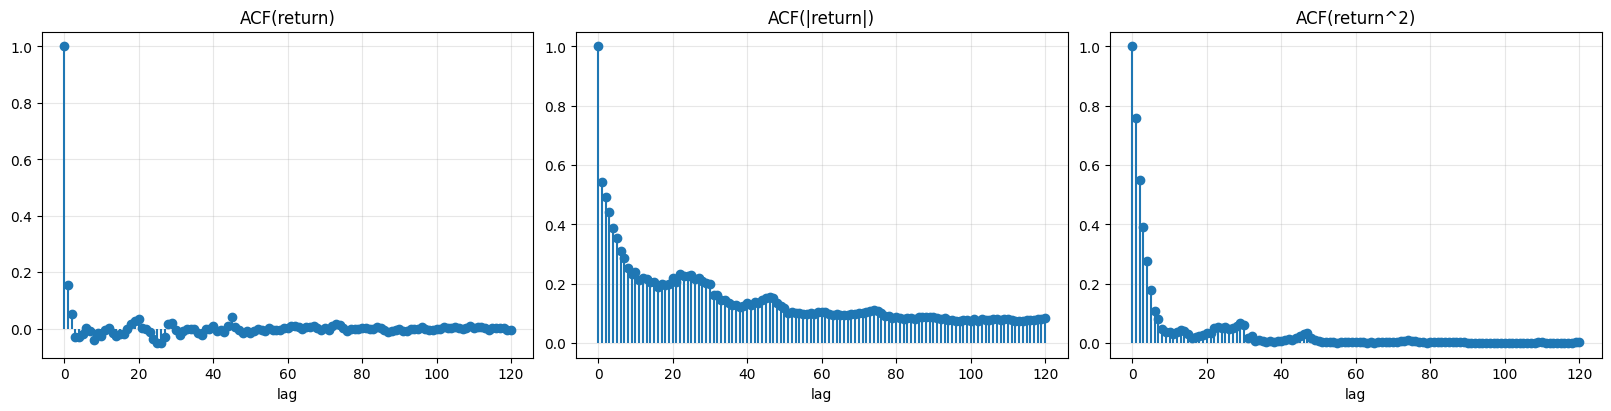

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
axes[0].stem(acf_df["lag"], acf_df["acf_return"], basefmt=" ")
axes[0].set_title("ACF(return)")
axes[1].stem(acf_df["lag"], acf_df["acf_abs_return"], basefmt=" ")
axes[1].set_title("ACF(|return|)")
axes[2].stem(acf_df["lag"], acf_df["acf_squared_return"], basefmt=" ")
axes[2].set_title("ACF(return^2)")
for ax in axes:
    ax.set_xlabel("lag")
    ax.grid(True, alpha=0.3)
acf_plot_path = OUTPUT_DIR / "acf_volatility_diagnostics.png"
fig.savefig(acf_plot_path, dpi=160)
acf_plot_path

## Exogenous Blocks

In [15]:
def top_by_variance(cols, limit):
    if not cols:
        return []
    variances = data[cols].var(numeric_only=True).sort_values(ascending=False)
    return variances.head(min(limit, len(variances))).index.tolist()


def drop_highly_correlated(cols, threshold=EXOG_CORRELATION_THRESHOLD):
    if len(cols) <= 1:
        return cols
    corr = data[cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop = {col for col in upper.columns if (upper[col] >= threshold).any()}
    return [col for col in cols if col not in drop]


btc_cols = top_by_variance(btc_cols_all, BTC_FEATURE_LIMIT)
aggression_cols = top_by_variance(aggression_cols_all, AGGRESSION_FEATURE_LIMIT)
pressure_cols = top_by_variance(pressure_cols_all, PRESSURE_FEATURE_LIMIT)

btc_cols = drop_highly_correlated(btc_cols)
aggression_cols = drop_highly_correlated(aggression_cols)
pressure_cols = drop_highly_correlated(pressure_cols)
combined_cols = drop_highly_correlated(list(dict.fromkeys(btc_cols + aggression_cols + pressure_cols)))

feature_blocks = {
    "GARCH": [],
    "GARCHX_BTC": btc_cols,
    "GARCHX_Aggression": aggression_cols,
    "GARCHX_Pressure": pressure_cols,
    "GARCHX_Combined": combined_cols,
}

for name, cols in feature_blocks.items():
    print(name, len(cols))
    print(cols[:8])

GARCH 0
[]
GARCHX_BTC 12
['btc_features__btc_zscore__lag_30', 'btc_features__btc_zscore__lag_15', 'btc_features__btc_zscore__lag_10', 'btc_features__btc_zscore__lag_5', 'btc_features__btc_zscore__lag_3', 'btc_features__btc_zscore__lag_2', 'btc_features__btc_zscore__lag_1', 'btc_features__btc_zscore__lag_60']
GARCHX_Aggression 8
['aggression_features__delta_quote_norm__roll_abs_sum_60', 'aggression_features__delta_base_norm__roll_sum_60', 'aggression_features__delta_base_norm__roll_sum_30', 'aggression_features__delta_quote_norm__roll_abs_sum_30', 'aggression_features__delta_base_norm__roll_sum_15', 'aggression_features__delta_quote_norm__roll_abs_sum_15', 'aggression_features__delta_base_norm__roll_sum_5', 'aggression_features__delta_quote_norm__roll_abs_sum_5']
GARCHX_Pressure 16
['price_pressure__F_asymmetry__lag_3', 'price_pressure__F_asymmetry__lag_1', 'price_pressure__F_asymmetry__lag_10', 'price_pressure__F_asymmetry__lag_2', 'price_pressure__F_asymmetry__lag_5', 'price_pressure_

## Fit GARCH Models

In [16]:
def fit_arch_model(name, y_train, exog_train=None, mean="Constant"):
    model = arch_model(
        y_train,
        x=exog_train,
        mean=mean,
        lags=0,
        vol="GARCH",
        p=1,
        q=1,
        dist="t",
        rescale=False,
    )
    return model.fit(disp="off", show_warning=False)


def mean_prediction_from_params(params, exog):
    const = float(params.get("Const", params.get("mu", 0.0)))
    pred = np.full(len(exog), const, dtype="float64")
    if exog is not None and len(exog.columns):
        for col in exog.columns:
            if col in params.index:
                pred += float(params[col]) * exog[col].to_numpy(dtype="float64")
    return pred


def recursive_garch_variance(params, y_full, exog_full, split_idx, initial_sigma2):
    omega = float(params["omega"])
    alpha = float(params[[idx for idx in params.index if idx.startswith("alpha[")][0]])
    beta = float(params[[idx for idx in params.index if idx.startswith("beta[")][0]])

    mean_full = mean_prediction_from_params(params, exog_full)
    sigma2 = np.empty(len(y_full), dtype="float64")
    sigma2[:split_idx] = np.nan
    prev_sigma2 = float(initial_sigma2)
    prev_eps = float(y_full[split_idx - 1] - mean_full[split_idx - 1])

    for idx in range(split_idx, len(y_full)):
        current_sigma2 = omega + alpha * prev_eps**2 + beta * prev_sigma2
        current_sigma2 = max(current_sigma2, 1e-12)
        sigma2[idx] = current_sigma2
        prev_sigma2 = current_sigma2
        prev_eps = float(y_full[idx] - mean_full[idx])
    return sigma2[split_idx:], mean_full[split_idx:]


def volatility_metrics(y_true, mean_pred, variance_pred):
    eps = y_true - mean_pred
    realized_abs = np.abs(eps)
    realized_var = eps**2
    pred_vol = np.sqrt(variance_pred)
    pred_var = variance_pred
    return {
        "mean_rmse": float(np.sqrt(np.mean((y_true - mean_pred) ** 2))),
        "vol_rmse_abs_return": float(np.sqrt(np.mean((realized_abs - pred_vol) ** 2))),
        "variance_rmse_return_sq": float(np.sqrt(np.mean((realized_var - pred_var) ** 2))),
        "vol_corr_abs_return": float(np.corrcoef(realized_abs, pred_vol)[0, 1]),
        "variance_corr_return_sq": float(np.corrcoef(realized_var, pred_var)[0, 1]),
        "mean_predicted_vol": float(np.mean(pred_vol)),
        "mean_realized_abs_return": float(np.mean(realized_abs)),
    }


def safe_param_diagnostics(result):
    try:
        pvalues = result.pvalues.reindex(result.params.index)
        std_err = result.std_err.reindex(result.params.index)
        status = "ok"
    except np.linalg.LinAlgError as exc:
        pvalues = pd.Series(np.nan, index=result.params.index, name="pvalues")
        std_err = pd.Series(np.nan, index=result.params.index, name="std_err")
        status = f"covariance_failed: {exc}"
    except Exception as exc:
        pvalues = pd.Series(np.nan, index=result.params.index, name="pvalues")
        std_err = pd.Series(np.nan, index=result.params.index, name="std_err")
        status = f"diagnostics_failed: {type(exc).__name__}: {exc}"
    return pvalues, std_err, status


model_rows = []
coef_frames = []
forecast_frames = []

y_full = y.to_numpy(dtype="float64")
for name, cols in feature_blocks.items():
    print("fit", name)
    exog_full = data[cols].astype("float64") if cols else pd.DataFrame(index=data.index)
    exog_train = exog_full.iloc[:split_idx] if cols else None
    mean = "ARX" if cols else "Constant"
    result = fit_arch_model(name, train_y, exog_train, mean=mean)
    params = result.params
    variance_pred, mean_pred = recursive_garch_variance(
        params=params,
        y_full=y_full,
        exog_full=exog_full,
        split_idx=split_idx,
        initial_sigma2=float(result.conditional_volatility.iloc[-1] ** 2),
    )
    test_values = y_full[split_idx:]
    row = {
        "model": name,
        "exog_features": len(cols),
        "aic": float(result.aic),
        "bic": float(result.bic),
        "loglikelihood": float(result.loglikelihood),
        "omega": float(params["omega"]),
        "alpha": float(params[[idx for idx in params.index if idx.startswith("alpha[")][0]]),
        "beta": float(params[[idx for idx in params.index if idx.startswith("beta[")][0]]),
    }
    row["persistence_alpha_plus_beta"] = row["alpha"] + row["beta"]
    row.update(volatility_metrics(test_values, mean_pred, variance_pred))
    pvalues, std_err, diagnostic_status = safe_param_diagnostics(result)
    row["param_diagnostics_status"] = diagnostic_status
    model_rows.append(row)

    coef_frames.append(pd.DataFrame({
        "model": name,
        "term": result.params.index,
        "coefficient": result.params.to_numpy(),
        "std_err": std_err.to_numpy(),
        "pvalue": pvalues.to_numpy(),
        "significant": pvalues.to_numpy() < 0.05,
        "diagnostic_status": diagnostic_status,
    }))
    forecast_frames.append(pd.DataFrame({
        "timestamp": data[TIME_COL].iloc[split_idx:].to_numpy(),
        "model": name,
        "actual_return_scaled": test_values,
        "mean_prediction": mean_pred,
        "variance_prediction": variance_pred,
        "volatility_prediction": np.sqrt(variance_pred),
    }))

model_metrics_df = pd.DataFrame(model_rows).sort_values("vol_rmse_abs_return").reset_index(drop=True)
coef_df = pd.concat(coef_frames, ignore_index=True)
forecast_df = pd.concat(forecast_frames, ignore_index=True)
display(model_metrics_df)
display(coef_df.head(40))

fit GARCH
fit GARCHX_BTC
fit GARCHX_Aggression
fit GARCHX_Pressure
fit GARCHX_Combined


,model,exog_features,aic,bic,loglikelihood,omega,alpha,beta,persistence_alpha_plus_beta,mean_rmse,vol_rmse_abs_return,variance_rmse_return_sq,vol_corr_abs_return,variance_corr_return_sq,mean_predicted_vol,mean_realized_abs_return,param_diagnostics_status
0,GARCH,0,-3.985381e+04,-3.980043e+04,1.993190e+04,0.122345,0.455727,2.821755e-07,0.455727,1.107251e-01,2.971313e-01,1.616627e-01,0.300498,0.426725,3.566460e-01,7.082323e-02,ok
1,GARCHX_BTC,12,2.401182e+06,2.401364e+06,-1.200574e+06,0.005965,0.100593,8.535043e-01,0.954097,9.815809e+00,5.333315e+00,1.344249e+02,0.321952,0.330731,7.783361e+00,8.066630e+00,ok
2,GARCHX_Aggression,8,1.787113e+07,1.787127e+07,-8.935554e+06,0.000645,0.100804,8.801073e-01,0.980912,8.675120e+03,8.098547e+02,1.478209e+07,0.978783,0.977534,7.771844e+03,8.468347e+03,ok
3,GARCHX_Pressure,16,6.955792e+07,6.955814e+07,-3.477894e+07,0.221241,0.999997,2.266615e-07,0.999998,1.860369e+16,1.824453e+13,7.373066e+29,0.966513,0.966513,1.860353e+16,1.860355e+16,covariance_failed: Singular matrix
4,GARCHX_Combined,36,6.956770e+07,6.956814e+07,-3.478381e+07,0.221156,0.999996,4.090286e-07,0.999996,1.869915e+16,1.833830e+13,7.449002e+29,0.966514,0.966514,1.869898e+16,1.869901e+16,covariance_failed: Singular matrix


,model,term,coefficient,std_err,pvalue,significant,diagnostic_status
0,GARCH,mu,-4.247283e-05,0.000151,7.788362e-01,False,ok
1,GARCH,omega,1.223450e-01,0.001552,0.000000e+00,True,ok
2,GARCH,alpha[1],4.557266e-01,0.202312,2.428465e-02,True,ok
3,GARCH,beta[1],2.821755e-07,0.005231,9.999570e-01,False,ok
4,GARCH,nu,1.857074e+02,2.484174,0.000000e+00,True,ok
5,GARCHX_BTC,Const,1.965892e+00,0.301012,6.535336e-11,True,ok
6,GARCHX_BTC,btc_features__btc_zscore__lag_30,-2.681998e+00,0.028453,0.000000e+00,True,ok
7,GARCHX_BTC,btc_features__btc_zscore__lag_15,-1.471456e+00,0.027382,0.000000e+00,True,ok
8,GARCHX_BTC,btc_features__btc_zscore__lag_10,-1.013421e+00,0.029550,9.183731e-258,True,ok
9,GARCHX_BTC,btc_features__btc_zscore__lag_5,-6.991441e-02,0.032484,3.137385e-02,True,ok


## Alternative Target Forms

In [17]:
alternative_targets = {
    "return": train_y,
    "abs_return": np.abs(train_y),
    "return_squared": train_y**2,
}
alt_rows = []
for name, series in alternative_targets.items():
    print("fit alternative", name)
    result = arch_model(series, mean="Constant", vol="GARCH", p=1, q=1, dist="t", rescale=False).fit(disp="off", show_warning=False)
    params = result.params
    alpha = float(params[[idx for idx in params.index if idx.startswith("alpha[")][0]])
    beta = float(params[[idx for idx in params.index if idx.startswith("beta[")][0]])
    alt_rows.append({
        "target_form": name,
        "aic": float(result.aic),
        "bic": float(result.bic),
        "omega": float(params["omega"]),
        "alpha": alpha,
        "beta": beta,
        "persistence_alpha_plus_beta": alpha + beta,
    })
alternative_targets_df = pd.DataFrame(alt_rows).sort_values("aic").reset_index(drop=True)
display(alternative_targets_df)

fit alternative return
fit alternative abs_return
fit alternative return_squared


,target_form,aic,bic,omega,alpha,beta,persistence_alpha_plus_beta
0,return,-3.985381e+04,-3.980043e+04,0.122345,0.455727,2.821755e-07,0.455727
1,abs_return,3.585656e+05,3.586190e+05,0.002727,0.958666,1.534610e-02,0.974013
2,return_squared,2.431477e+06,2.431531e+06,0.021108,0.899153,5.568936e-02,0.954843


## Regime Stability

In [18]:
regime_rows = []
for model_name, group in forecast_df.groupby("model"):
    group = group.sort_values("timestamp").reset_index(drop=True)
    chunks = np.array_split(group, REGIME_CHUNKS)
    for idx, chunk in enumerate(chunks, start=1):
        eps = chunk["actual_return_scaled"] - chunk["mean_prediction"]
        realized_abs = np.abs(eps)
        pred_vol = chunk["volatility_prediction"]
        regime_rows.append({
            "model": model_name,
            "regime_chunk": idx,
            "start": str(chunk["timestamp"].min()),
            "end": str(chunk["timestamp"].max()),
            "vol_rmse_abs_return": float(np.sqrt(np.mean((realized_abs - pred_vol) ** 2))),
            "vol_corr_abs_return": float(np.corrcoef(realized_abs, pred_vol)[0, 1]),
            "mean_predicted_vol": float(pred_vol.mean()),
            "mean_realized_abs_return": float(realized_abs.mean()),
        })
regime_stability_df = pd.DataFrame(regime_rows)
display(regime_stability_df.head(40))

,model,regime_chunk,start,end,vol_rmse_abs_return,vol_corr_abs_return,mean_predicted_vol,mean_realized_abs_return
0,GARCH,1,2025-12-08 10:40:00+00:00,2025-12-15 09:19:00+00:00,2.918923e-01,0.254076,3.576261e-01,7.752065e-02
1,GARCH,2,2025-12-15 09:20:00+00:00,2025-12-22 07:59:00+00:00,2.941882e-01,0.267643,3.573818e-01,7.483704e-02
2,GARCH,3,2025-12-22 08:00:00+00:00,2025-12-29 06:39:00+00:00,3.009912e-01,0.232678,3.550378e-01,6.192427e-02
3,GARCH,4,2025-12-29 06:40:00+00:00,2026-01-05 05:19:00+00:00,2.984046e-01,0.188351,3.554055e-01,6.528375e-02
4,GARCH,5,2026-01-05 05:20:00+00:00,2026-01-12 03:59:00+00:00,2.924966e-01,0.230043,3.566547e-01,7.369223e-02
5,GARCH,6,2026-01-12 04:00:00+00:00,2026-01-19 02:39:00+00:00,3.009414e-01,0.386834,3.561465e-01,6.728780e-02
6,GARCH,7,2026-01-19 02:40:00+00:00,2026-01-26 01:19:00+00:00,3.000893e-01,0.191811,3.553653e-01,6.381012e-02
7,GARCH,8,2026-01-26 01:20:00+00:00,2026-02-01 23:59:00+00:00,2.978823e-01,0.376737,3.595500e-01,8.222996e-02
8,GARCHX_Aggression,1,2025-12-08 10:40:00+00:00,2025-12-15 09:19:00+00:00,7.412161e+02,0.979829,7.054487e+03,7.690999e+03
9,GARCHX_Aggression,2,2025-12-15 09:20:00+00:00,2025-12-22 07:59:00+00:00,8.192703e+02,0.977514,7.771026e+03,8.466228e+03


## Plots

WindowsPath('model_artifacts/garch_volatility_diagnostics/garch_model_comparison.png')

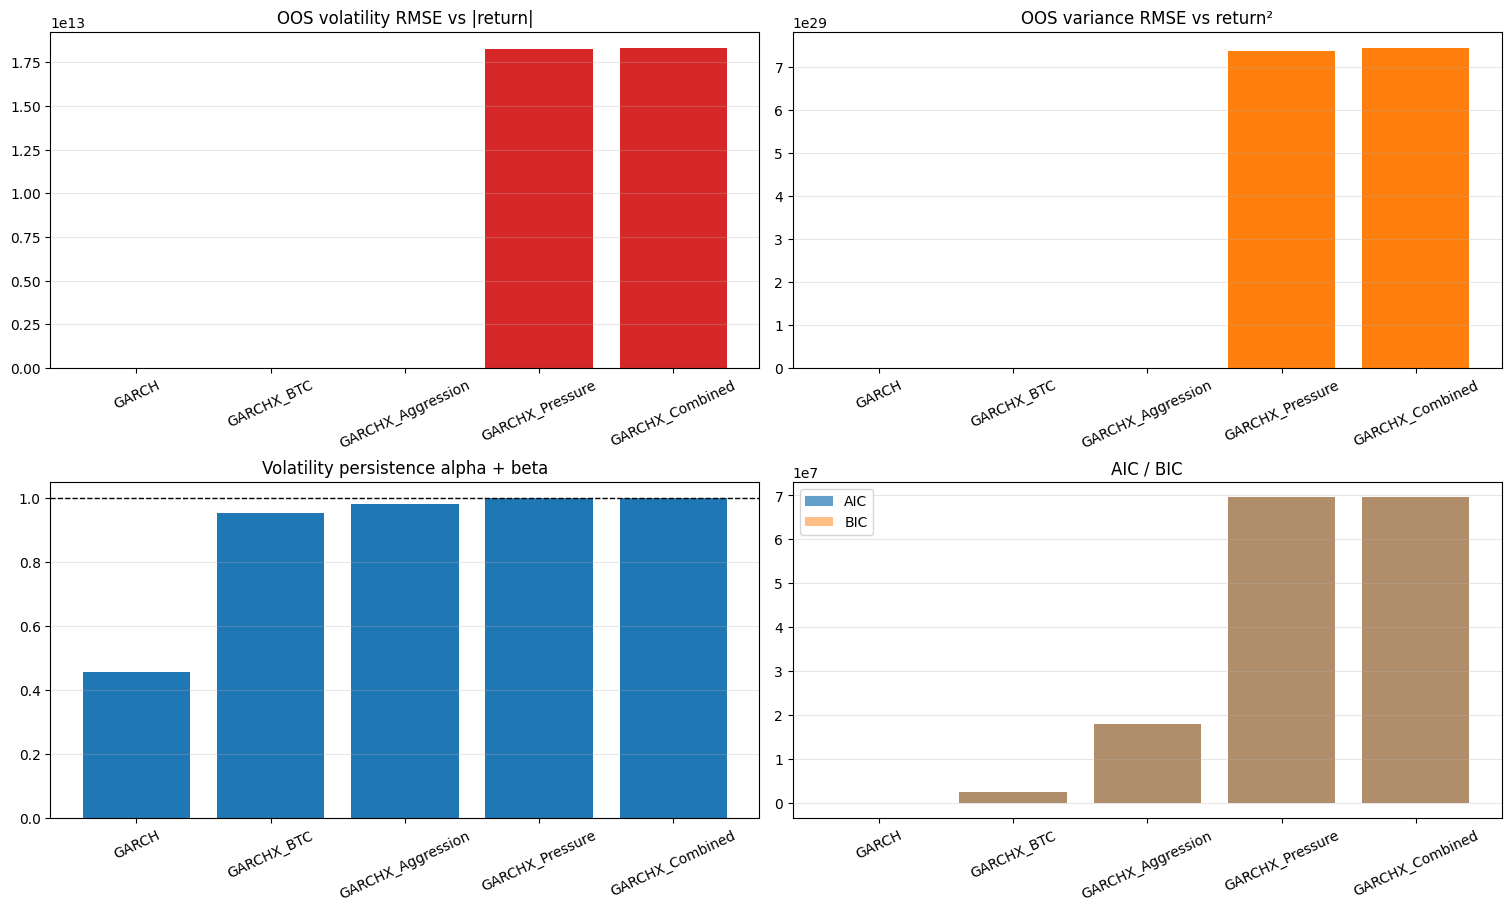

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)

axes[0, 0].bar(model_metrics_df["model"], model_metrics_df["vol_rmse_abs_return"], color="tab:red")
axes[0, 0].set_title("OOS volatility RMSE vs |return|")
axes[0, 0].tick_params(axis="x", rotation=25)
axes[0, 0].grid(True, axis="y", alpha=0.3)

axes[0, 1].bar(model_metrics_df["model"], model_metrics_df["variance_rmse_return_sq"], color="tab:orange")
axes[0, 1].set_title("OOS variance RMSE vs return²")
axes[0, 1].tick_params(axis="x", rotation=25)
axes[0, 1].grid(True, axis="y", alpha=0.3)

axes[1, 0].bar(model_metrics_df["model"], model_metrics_df["persistence_alpha_plus_beta"], color="tab:blue")
axes[1, 0].axhline(1.0, linestyle="--", color="black", linewidth=1)
axes[1, 0].set_title("Volatility persistence alpha + beta")
axes[1, 0].tick_params(axis="x", rotation=25)
axes[1, 0].grid(True, axis="y", alpha=0.3)

axes[1, 1].bar(model_metrics_df["model"], model_metrics_df["aic"], alpha=0.7, label="AIC")
axes[1, 1].bar(model_metrics_df["model"], model_metrics_df["bic"], alpha=0.5, label="BIC")
axes[1, 1].set_title("AIC / BIC")
axes[1, 1].tick_params(axis="x", rotation=25)
axes[1, 1].legend()
axes[1, 1].grid(True, axis="y", alpha=0.3)

metrics_plot_path = OUTPUT_DIR / "garch_model_comparison.png"
fig.savefig(metrics_plot_path, dpi=160)
metrics_plot_path

WindowsPath('model_artifacts/garch_volatility_diagnostics/conditional_volatility_dynamics.png')

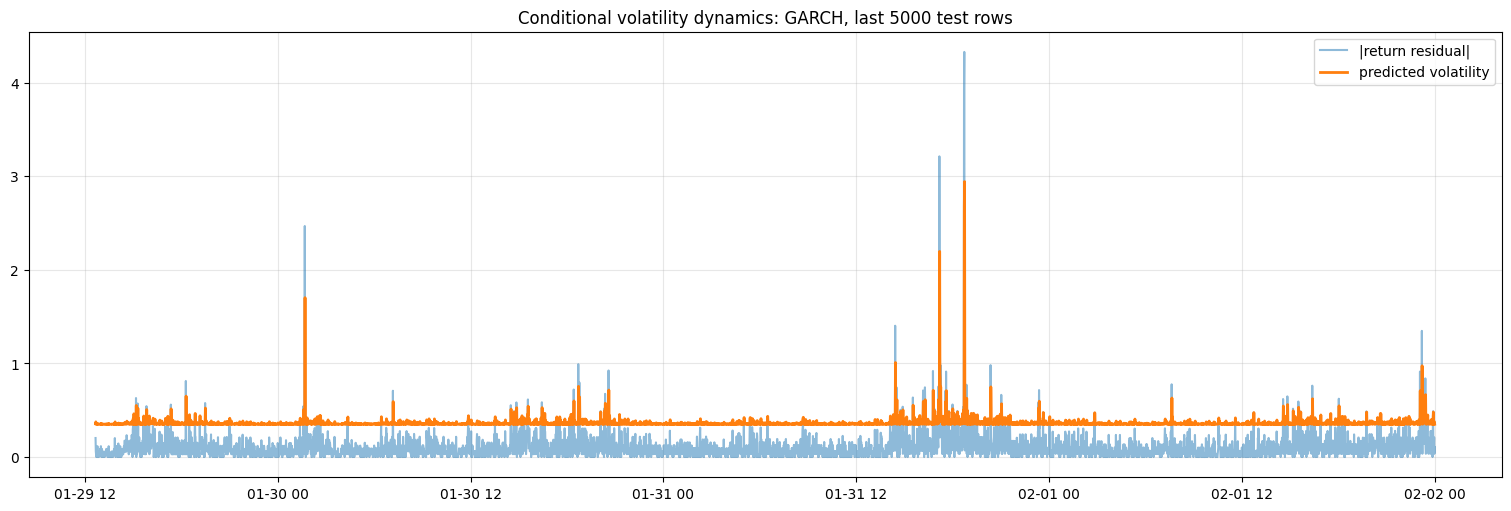

In [20]:
baseline_name = model_metrics_df.iloc[0]["model"]
baseline_forecast = forecast_df[forecast_df["model"] == baseline_name].sort_values("timestamp").tail(5_000)
fig, ax = plt.subplots(figsize=(15, 5), constrained_layout=True)
ax.plot(baseline_forecast["timestamp"], np.abs(baseline_forecast["actual_return_scaled"] - baseline_forecast["mean_prediction"]), label="|return residual|", alpha=0.5)
ax.plot(baseline_forecast["timestamp"], baseline_forecast["volatility_prediction"], label="predicted volatility", linewidth=2)
ax.set_title(f"Conditional volatility dynamics: {baseline_name}, last 5000 test rows")
ax.legend()
ax.grid(True, alpha=0.3)
vol_plot_path = OUTPUT_DIR / "conditional_volatility_dynamics.png"
fig.savefig(vol_plot_path, dpi=160)
vol_plot_path

## Save Outputs

In [21]:
acf_df.to_csv(OUTPUT_DIR / "acf_diagnostics.csv", index=False)
diagnostics_df.to_csv(OUTPUT_DIR / "arch_lm_ljungbox_diagnostics.csv", index=False)
model_metrics_df.to_csv(OUTPUT_DIR / "garch_model_metrics.csv", index=False)
coef_df.to_csv(OUTPUT_DIR / "garch_coefficients.csv", index=False)
alternative_targets_df.to_csv(OUTPUT_DIR / "garch_alternative_target_forms.csv", index=False)
regime_stability_df.to_csv(OUTPUT_DIR / "garch_regime_stability.csv", index=False)
forecast_df.to_parquet(OUTPUT_DIR / "garch_oos_forecasts.parquet", index=False, compression="zstd")

report = {
    "temporal_dataset": str(TEMPORAL_DATASET),
    "rows_used": int(len(data)),
    "return_scale": RETURN_SCALE,
    "train_fraction": TRAIN_FRACTION,
    "diagnostics": diagnostics_df.to_dict(orient="records"),
    "model_metrics": model_metrics_df.to_dict(orient="records"),
    "alternative_target_forms": alternative_targets_df.to_dict(orient="records"),
    "feature_blocks": feature_blocks,
    "plots": {
        "acf": str(acf_plot_path),
        "model_comparison": str(metrics_plot_path),
        "conditional_volatility": str(vol_plot_path),
    },
}
(OUTPUT_DIR / "garch_volatility_report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")

print("saved to", OUTPUT_DIR)

saved to model_artifacts\garch_volatility_diagnostics
